# Team Analysis--Puneri Paltan Pro Kabaddi League Season 10

In [1]:
import kabaddiPy 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pkl=kabaddiPy.PKL()

Going With Puneri Paltan with id 7

In [3]:
ids=pkl.get_team_ids(season=10)
ids

,Team_Id,Team_Name
0,7,Puneri Paltan
1,3,Jaipur Pink Panthers
2,2,Dabang Delhi K.C.
3,31,Gujarat Giants
4,28,Haryana Steelers
5,6,Patna Pirates
6,4,Bengal Warriorz
7,1,Bengaluru Bulls
8,29,Tamil Thalaivas
9,5,U Mumba


All the matches of Puneri Paltan from season 10

In [4]:
team=pkl.get_team_matches(season=10,team_id=7)
team.head()

,Season,Match_ID,Match_Name,League_Stage,Year,Venue,Match_Outcome,Start_Date,End_Date,Result,Winning Margin,team_score_1,team_score_2,team_name_1,team_id_1,team_name_2,team_id_2
4,10,3033,Match 5,League,2023,"Eka Arena By Transstadia, Ahmedabad",Puneri Paltan won by 4 Pts,2023-12-04T20:00+05:30,2023-12-04T20:00+05:30,W,4,37,33,Puneri Paltan,7,Jaipur Pink Panthers,3
12,10,3041,Match 13,League,2023,"Shree Kanteerava Indoor Stadium, Bengaluru",Puneri Paltan won by 11 Pts,2023-12-08T21:00+05:30,2023-12-08T21:00+05:30,W,11,43,32,Puneri Paltan,7,U Mumba,5
23,10,3052,Match 24,League,2023,"Badminton Hall In Balewadi Sports Complex,Pune...",Haryana Steelers won by 5 Pts,2023-12-15T21:00+05:30,2023-12-15T21:00+05:30,W,5,39,44,Puneri Paltan,7,Haryana Steelers,28
24,10,3053,Match 25,League,2023,"Badminton Hall In Balewadi Sports Complex,Pune...",Puneri Paltan won by 30 Pts,2023-12-16T20:00+05:30,2023-12-16T20:00+05:30,W,30,49,19,Puneri Paltan,7,Bengal Warriors,4
29,10,3058,Match 30,League,2023,"Badminton Hall In Balewadi Sports Complex,Pune...",Puneri Paltan won by 7 Pts,2023-12-18T21:00+05:30,2023-12-18T21:00+05:30,W,7,30,23,Puneri Paltan,7,Dabang Delhi K.C.,2


In [5]:
df=team

In [6]:
df.shape

(24, 17)

Wins vs losses/ties of the team from the season

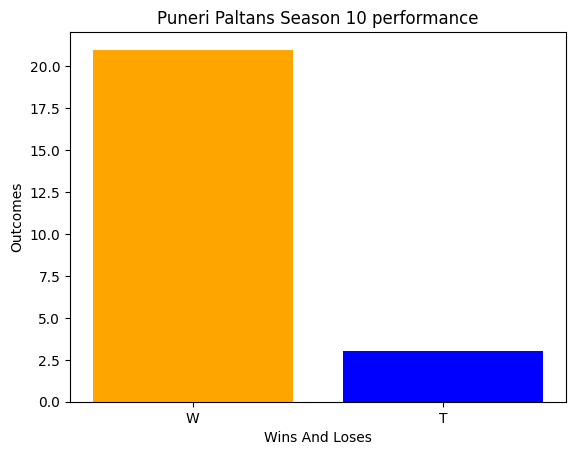

In [7]:
result=df.Result.value_counts()
result
plt.bar(result.index,result.values,color=["Orange","Blue"])
plt.xlabel("Wins And Loses")
plt.ylabel("Outcomes")
plt.title("Puneri Paltans Season 10 performance")
plt.show()


Lost/Tied Matches by the team 

In [8]:
#Tied matches
lose=df[df["Result"]=="T"]
lose


,Season,Match_ID,Match_Name,League_Stage,Year,Venue,Match_Outcome,Start_Date,End_Date,Result,Winning Margin,team_score_1,team_score_2,team_name_1,team_id_1,team_name_2,team_id_2
85,10,3114,Match 86,League,2023,"Gmc Balayogi Sports Complex, Gachibowli, Hyder...",Match Tied,2024-01-23T20:00+05:30,2024-01-23T20:00+05:30,T,,32,32,U Mumba,5,Puneri Paltan,7
90,10,3119,Match 91,League,2023,"Patliputra Indoor Stadium, Patna",Match Tied,2024-01-27T20:00+05:30,2024-01-27T20:00+05:30,T,,32,32,Patna Pirates,6,Puneri Paltan,7
106,10,3135,Match 107,League,2023,"Thyagaraj Indoor Stadium, Delhi",Match Tied,2024-02-05T21:00+05:30,2024-02-05T21:00+05:30,T,,30,30,Dabang Delhi K.C.,2,Puneri Paltan,7


Points Scored by opponents and Puneri Paltan against each other

Text(0.5, 1.0, 'Total points against teams')

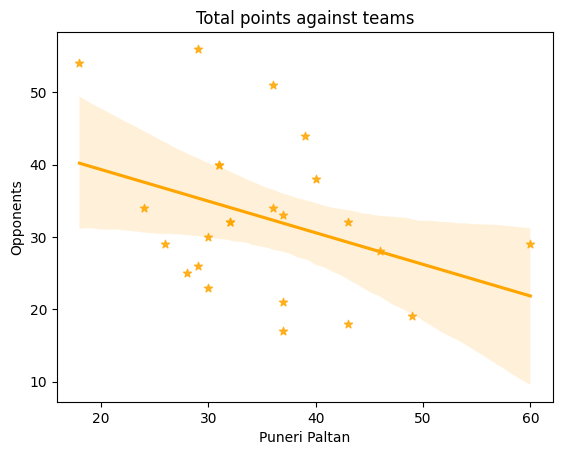

In [9]:
df['team_score_1']=pd.to_numeric(df['team_score_1'])
df['team_score_2']=pd.to_numeric(df['team_score_2'])
sns.regplot(data=df,x='team_score_1',y='team_score_2',scatter=True,color="Orange",marker="*")
plt.xlabel("Puneri Paltan")
plt.ylabel("Opponents")
plt.title("Total points against teams")


Winning Percentage of the team for Season 10

In [10]:
#Win percentage
winpercent=(df["Result"]=="W").mean()*100
print(f"Win % for platan : {winpercent} %")

Win % for platan : 87.5 %


In [11]:
df['Winning Margin']=pd.to_numeric(df['Winning Margin'])
high_margin=df[df['Winning Margin']>=10].shape[0]
print(high_margin)
low_margin=df[df['Winning Margin']<10].shape[0]
low_margin

11


10

Wins by the team segregated by Winning margins

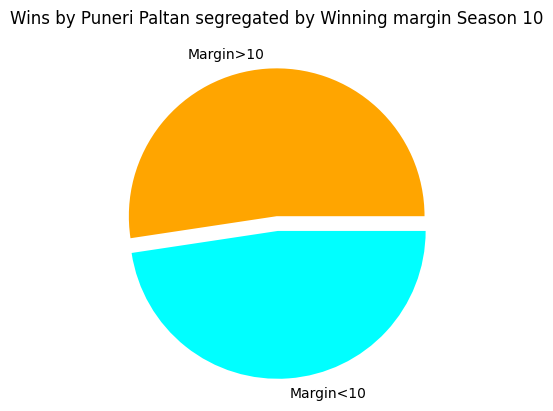

In [12]:
plt.pie([high_margin,low_margin],labels=["Margin>10","Margin<10"],labeldistance=1.1,explode=[0,0.1],colors=["Orange","Cyan"])
plt.title("Wins by Puneri Paltan segregated by Winning margin Season 10")
plt.savefig("Winning Margins.png")

Lossed/Tied matches of Puneri Paltan against teams

In [13]:
losses = df[df['Result'] == "T"]
losses_against = losses['team_name_1'].value_counts()
losses_against.head()

team_name_1
U Mumba              1
Patna Pirates        1
Dabang Delhi K.C.    1
Name: count, dtype: int64

Graph for the same

Text(0.5, 1.0, 'Matches lost by Puner Paltan Season 10')

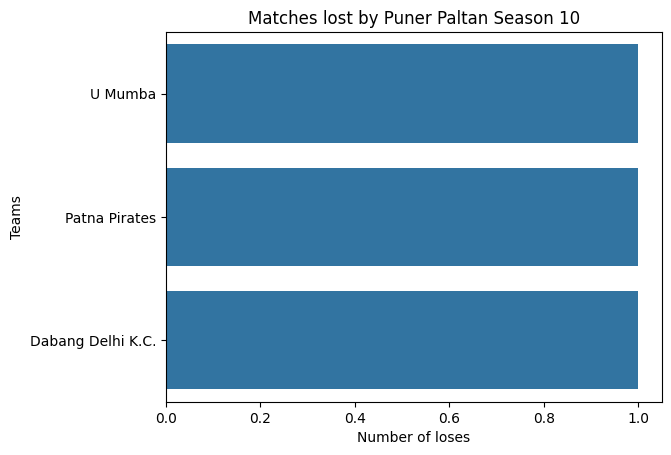

In [14]:
# plt.figure(figsize=(8,5))
sns.barplot(y=losses_against.index,x=losses_against.values)
plt.xlabel("Number of loses")
plt.ylabel("Teams")
plt.title("Matches lost by Puner Paltan Season 10")
